# GC Recent Intrabar Diagnostic

This notebook is a recent-data diagnostic workflow for manual out-of-sample intrabar inspection. It is intentionally separate from the main historical backtest.

Scope limits:

- Data source is `yfinance` (`GC=F`), not the main historical futures dataset.
- Coverage is only the recent 7-day intraday window allowed by the source.
- This notebook is for data inspection, session reconstruction, and hourly context building.
- It is not a replacement for the main backtest and does not make long-history claims.


## 0. Configuration

The defaults are intentionally conservative: use a local cache first and refresh only when you explicitly set `force_refresh = True`.


In [1]:
from pathlib import Path

from gold_breakout_intrabar_recent import (
    RecentIntrabarConfig,
    recent_intrabar_config_frame,
)

config = RecentIntrabarConfig(
    ticker="GC=F",
    period="7d",
    interval="1m",
    cache_dir=Path("cache") / "yfinance_intrabar_recent",
    session_gap_threshold_minutes=30,
)

recent_intrabar_config_frame(config)


,parameter,value
0,ticker,GC=F
1,period,7d
2,interval,1m
3,cache_dir,cache\yfinance_intrabar_recent
4,session_gap_threshold_minutes,30


## 1. Imports

The helper module handles cache paths, `yfinance` normalization, session construction, and hourly resampling.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from gold_breakout_intrabar_recent import (
    build_recent_intrabar_context,
    recent_intrabar_cache_paths,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## 2. Load Cached Or Recent Data

Set `force_refresh = True` only when you want to download the latest 7-day sample from `yfinance`.


In [3]:
force_refresh = False

context = build_recent_intrabar_context(config, force_refresh=force_refresh)
minute_bars = context["minute_bars"]
session_table = context["session_table"]
hourly_bars = context["hourly_bars"]
metadata = context["metadata"]
cache_paths = context["cache_paths"]

display(pd.DataFrame([metadata]))
display(pd.DataFrame({"path_type": list(cache_paths.keys()), "path": [str(path) for path in cache_paths.values()]}))
print(f"minute rows: {len(minute_bars):,}")
print(f"sessions: {len(session_table):,}")
print(f"hourly rows: {len(hourly_bars):,}")


,source,ticker,period,interval,rows,downloaded_at_utc,ts_min,ts_max,cache_hit
0,yfinance,GC=F,7d,1m,7462,2026-03-31T14:29:32.894110+00:00,2026-03-24T04:00:00+00:00,2026-03-31T14:19:00+00:00,False


,path_type,path
0,bars_csv,cache\yfinance_intrabar_recent\GC_F_7d_1m.csv
1,metadata_json,cache\yfinance_intrabar_recent\GC_F_7d_1m.meta...


minute rows: 7,462
sessions: 6
hourly rows: 126


## 3. Raw Data Preview

This view is just a sanity check on timestamp coverage, prices, and volume.


In [4]:
display(minute_bars.head(10))
display(minute_bars.tail(10))


,ts_event,ticker,open,high,low,close,adj_close,volume,session_id,session_open_ts,session_close_ts,session_date,session_open_bar,session_close_bar
0,2026-03-24 04:00:00+00:00,GC=F,4347.399902,4350.899902,4347.200195,4348.899902,4348.899902,0,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,True,False
1,2026-03-24 04:01:00+00:00,GC=F,4350.100098,4352.600098,4349.799805,4351.799805,4351.799805,28,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
2,2026-03-24 04:02:00+00:00,GC=F,4352.500000,4353.600098,4349.299805,4350.500000,4350.500000,37,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
3,2026-03-24 04:03:00+00:00,GC=F,4351.399902,4352.500000,4350.000000,4351.299805,4351.299805,31,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
4,2026-03-24 04:04:00+00:00,GC=F,4351.299805,4353.200195,4351.299805,4352.700195,4352.700195,14,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
5,2026-03-24 04:05:00+00:00,GC=F,4354.000000,4357.700195,4354.000000,4357.500000,4357.500000,21,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
6,2026-03-24 04:06:00+00:00,GC=F,4356.299805,4356.899902,4351.799805,4353.500000,4353.500000,36,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
7,2026-03-24 04:07:00+00:00,GC=F,4353.700195,4354.299805,4349.600098,4349.600098,4349.600098,34,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
8,2026-03-24 04:08:00+00:00,GC=F,4350.299805,4351.200195,4348.500000,4348.500000,4348.500000,20,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False
9,2026-03-24 04:09:00+00:00,GC=F,4349.100098,4352.700195,4348.600098,4352.600098,4352.600098,41,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,2026-03-24 00:00:00+00:00,False,False


,ts_event,ticker,open,high,low,close,adj_close,volume,session_id,session_open_ts,session_close_ts,session_date,session_open_bar,session_close_bar
7452,2026-03-31 14:10:00+00:00,GC=F,4635.600098,4637.100098,4634.200195,4635.799805,4635.799805,284,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7453,2026-03-31 14:11:00+00:00,GC=F,4635.799805,4640.299805,4634.500000,4637.299805,4637.299805,206,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7454,2026-03-31 14:12:00+00:00,GC=F,4636.700195,4640.799805,4635.700195,4637.399902,4637.399902,235,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7455,2026-03-31 14:13:00+00:00,GC=F,4637.600098,4642.000000,4636.399902,4640.500000,4640.500000,162,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7456,2026-03-31 14:14:00+00:00,GC=F,4640.200195,4646.200195,4639.799805,4646.200195,4646.200195,199,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7457,2026-03-31 14:15:00+00:00,GC=F,4645.799805,4645.799805,4640.700195,4641.500000,4641.500000,134,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7458,2026-03-31 14:16:00+00:00,GC=F,4641.100098,4642.600098,4637.500000,4639.200195,4639.200195,234,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7459,2026-03-31 14:17:00+00:00,GC=F,4639.600098,4641.899902,4638.000000,4638.000000,4638.000000,177,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7460,2026-03-31 14:18:00+00:00,GC=F,4637.799805,4645.500000,4637.500000,4642.100098,4642.100098,182,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,False
7461,2026-03-31 14:19:00+00:00,GC=F,4641.100098,4643.500000,4640.000000,4640.600098,4640.600098,0,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,2026-03-30 00:00:00+00:00,False,True


## 4. Session Reconstruction

Sessions are inferred from gaps larger than the configured threshold. This is a diagnostic heuristic for recent intraday data, not the canonical historical session engine.


In [5]:
display(session_table)


,session_id,session_open_ts,session_close_ts,session_bars,session_open,session_high,session_low,session_close,session_volume,session_date
0,0,2026-03-24 04:00:00+00:00,2026-03-24 20:59:00+00:00,1020,4347.399902,4485.600098,4319.899902,4474.899902,173408,2026-03-24 00:00:00+00:00
1,1,2026-03-24 22:00:00+00:00,2026-03-25 20:59:00+00:00,1379,4473.500000,4601.000000,4458.200195,4503.299805,237720,2026-03-24 00:00:00+00:00
2,2,2026-03-25 22:00:00+00:00,2026-03-26 20:59:00+00:00,1379,4508.899902,4541.600098,4348.200195,4376.899902,238665,2026-03-25 00:00:00+00:00
3,3,2026-03-26 22:00:00+00:00,2026-03-27 20:59:00+00:00,1336,4371.799805,4585.299805,4369.100098,4524.299805,202301,2026-03-26 00:00:00+00:00
4,4,2026-03-29 22:10:00+00:00,2026-03-30 20:59:00+00:00,1369,4510.100098,4611.399902,4444.700195,4540.399902,151989,2026-03-29 00:00:00+00:00
5,5,2026-03-30 22:00:00+00:00,2026-03-31 14:19:00+00:00,979,4538.899902,4656.100098,4510.000000,4640.600098,107068,2026-03-30 00:00:00+00:00


## 5. Hourly Aggregation From 1m Bars

The hourly table is a convenience view that helps compare recent minute data against the main strategy's bar-based structure.


In [6]:
display(hourly_bars.head(24))
display(hourly_bars.tail(24))


,session_id,session_date,ts_event,minute_count,open,high,low,close,adj_close,volume
0,0,2026-03-24 00:00:00+00:00,2026-03-24 04:00:00+00:00,60,4347.399902,4357.700195,4327.000000,4334.000000,4334.000000,2491
1,0,2026-03-24 00:00:00+00:00,2026-03-24 05:00:00+00:00,60,4334.500000,4375.399902,4319.899902,4349.500000,4349.500000,6232
2,0,2026-03-24 00:00:00+00:00,2026-03-24 06:00:00+00:00,60,4348.899902,4406.700195,4345.500000,4403.799805,4403.799805,6113
3,0,2026-03-24 00:00:00+00:00,2026-03-24 07:00:00+00:00,60,4402.500000,4437.600098,4401.000000,4420.200195,4420.200195,8472
4,0,2026-03-24 00:00:00+00:00,2026-03-24 08:00:00+00:00,60,4420.100098,4423.600098,4392.700195,4413.500000,4413.500000,8800
5,0,2026-03-24 00:00:00+00:00,2026-03-24 09:00:00+00:00,60,4413.100098,4432.200195,4397.299805,4427.700195,4427.700195,6689
6,0,2026-03-24 00:00:00+00:00,2026-03-24 10:00:00+00:00,60,4428.000000,4442.899902,4415.200195,4439.700195,4439.700195,7584
7,0,2026-03-24 00:00:00+00:00,2026-03-24 11:00:00+00:00,60,4438.899902,4443.200195,4372.399902,4408.000000,4408.000000,14144
8,0,2026-03-24 00:00:00+00:00,2026-03-24 12:00:00+00:00,60,4408.200195,4427.600098,4361.700195,4378.700195,4378.700195,15189
9,0,2026-03-24 00:00:00+00:00,2026-03-24 13:00:00+00:00,60,4379.000000,4390.700195,4350.399902,4382.500000,4382.500000,20103


,session_id,session_date,ts_event,minute_count,open,high,low,close,adj_close,volume
102,4,2026-03-29 00:00:00+00:00,2026-03-30 14:00:00+00:00,60,4553.200195,4571.899902,4542.000000,4569.200195,4569.200195,12896
103,4,2026-03-29 00:00:00+00:00,2026-03-30 15:00:00+00:00,60,4569.000000,4587.100098,4554.500000,4578.100098,4578.100098,9848
104,4,2026-03-29 00:00:00+00:00,2026-03-30 16:00:00+00:00,60,4578.399902,4580.000000,4560.100098,4569.500000,4569.500000,6762
105,4,2026-03-29 00:00:00+00:00,2026-03-30 17:00:00+00:00,60,4569.100098,4572.000000,4540.899902,4544.799805,4544.799805,8393
106,4,2026-03-29 00:00:00+00:00,2026-03-30 18:00:00+00:00,60,4545.100098,4553.100098,4528.000000,4528.799805,4528.799805,5198
107,4,2026-03-29 00:00:00+00:00,2026-03-30 19:00:00+00:00,60,4528.500000,4548.299805,4522.700195,4543.200195,4543.200195,5325
108,4,2026-03-29 00:00:00+00:00,2026-03-30 20:00:00+00:00,60,4543.700195,4547.000000,4530.200195,4540.399902,4540.399902,1970
109,5,2026-03-30 00:00:00+00:00,2026-03-30 22:00:00+00:00,60,4538.899902,4552.500000,4530.500000,4539.399902,4539.399902,1737
110,5,2026-03-30 00:00:00+00:00,2026-03-30 23:00:00+00:00,60,4539.100098,4550.100098,4520.799805,4542.100098,4542.100098,2139
111,5,2026-03-30 00:00:00+00:00,2026-03-31 00:00:00+00:00,60,4541.399902,4577.299805,4510.000000,4576.600098,4576.600098,7357


## 6. Static Recent Overview

This plot is deliberately simple: recent 1-minute closes, session boundaries, and hourly closes. Animation and richer intrabar logic belong in the next diagnostic step.


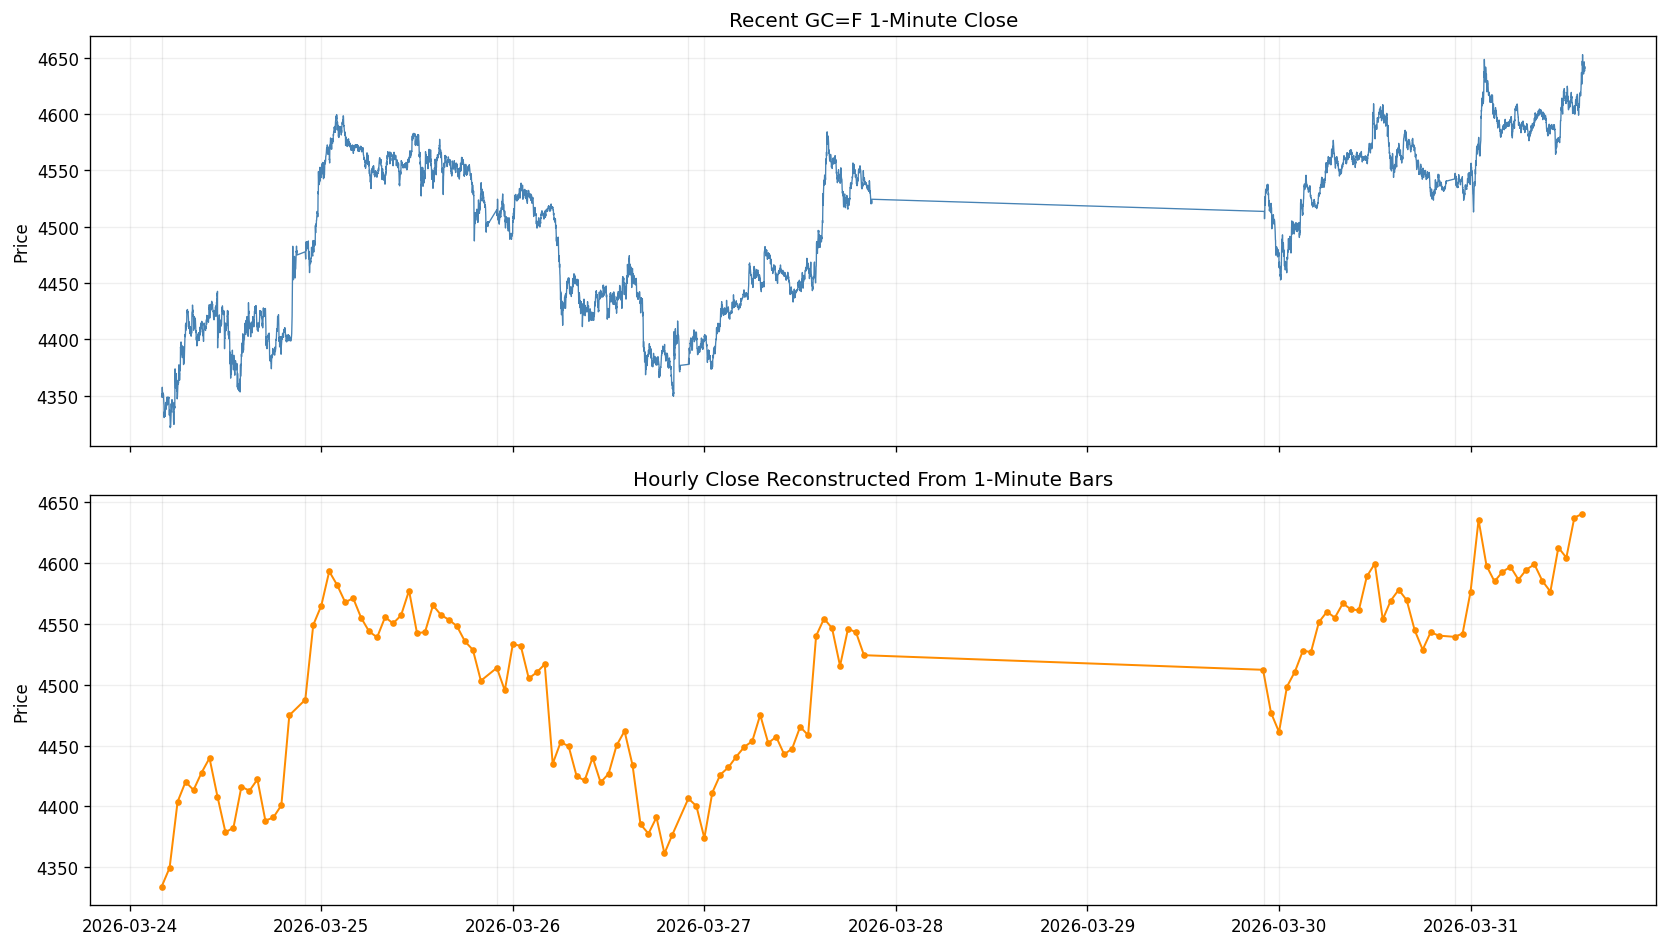

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(minute_bars["ts_event"], minute_bars["close"], color="steelblue", linewidth=0.8)
for session_open in session_table["session_open_ts"]:
    axes[0].axvline(session_open, color="grey", alpha=0.15, linewidth=0.8)
axes[0].set_title("Recent GC=F 1-Minute Close")
axes[0].set_ylabel("Price")
axes[0].grid(True, alpha=0.2)

axes[1].plot(hourly_bars["ts_event"], hourly_bars["close"], color="darkorange", linewidth=1.2, marker="o", markersize=3)
for session_open in session_table["session_open_ts"]:
    axes[1].axvline(session_open, color="grey", alpha=0.15, linewidth=0.8)
axes[1].set_title("Hourly Close Reconstructed From 1-Minute Bars")
axes[1].set_ylabel("Price")
axes[1].grid(True, alpha=0.2)

fig.tight_layout()
display(fig)
plt.close(fig)


## 7. Next-Step Hooks

This notebook now provides:

- recent 1-minute data with local cache
- inferred session boundaries
- hourly aggregation
- cache metadata and file locations

The next intrabar commit can build on this foundation to add richer replay/animation and manual execution-logic inspection.
